In [1]:
import os
import joblib
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf, ttest_ind
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
plot_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.2],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [4]:
# X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [5]:
# v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
# v1_scores = pd.read_pickle(v1_xs_file)
# v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
# Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
# P = joblib.load(
#     os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
# )

In [7]:
# modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
# with open(modfile, 'rb') as f:
#     optimized_model = pickle.load(f)

In [8]:
# loss_decay = optimized_model['loss_decay']
# last_epoch = loss_decay[-1]

In [9]:
# upper_bounds = [0.1, 0.2, 0.3]

# optimizations = []
# odf = {
#     'v1_unit': [],
#     'dlgn_unit': [],
#     'upper_bound': [],
#     'ampc': [],
#     'loss': [],
    
# }
# for v1 in range(2):
#     for dlgn in range(3):
#         for u in upper_bounds:
#             param_bounds = {
#                 "fts": [0, 175],
#                 "t": [40, 125],
#                 "ampc": [0.01, 0.1],
#                 'ampm': [0,3],
#                 "ampg": [0.1, 4],
#                 "ampw": [0.01, u],
#                 "d": [10, 40],
#                 "inh_d": [0, 40],
#                 "inh_w": [0, 3],
#             }

#             dLGN_params = optimized_model['scaled_param_history']['dLGN_params'][np.argsort(last_epoch)[:1000],-1]

#             model = SGCCircuit(param_bounds, enforce_permutation=P[:1000])
#             model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=1000)
#             model.update_transform()

#             dLGN_params[:,v1,dlgn,2,:,:] = model.dlgn_raw[:,v1,dlgn,2,:,:].numpy()

#             params = {
#                 'dLGN_params': dLGN_params,
#                 'V1_params': optimized_model['scaled_param_history']['V1_params'][np.argsort(last_epoch)[:1000],-1]
#             }

#             # apply a jitter
#             p = {x[0]:x[1] + tf.random.uniform(x[1].shape, -0.5, 0.5) 
#                 for x in params.items()}
            
#             model = SGCCircuit(param_bounds, enforce_permutation=P[:1000])
#             model.load_saved_parameters(p)

#             # initialize the optimizer
#             optimizer = Optimize(model, epochs=500, loss_threshold=0)

#             # fit the model
#             loss_decay = optimizer.fit(X, Y_true)
#             #optimizer.save_state(f'conditional_optimization_ampc_upper_{u}')
#             optimizations.append([
#                 optimizer.outputs['param_history']['dLGN_params'][:,-1][:,v1,dlgn,5,0,0], # x
#                 optimizer.outputs['loss_decay'][-1], # y
#             ])
#             odf['v1_unit']+=[f"{v1+1}"]*1000
#             odf['dlgn_unit']+=[f"{v1+1}_{dlgn+1}"]*1000
#             odf['upper_bound']+=[f"{u}"]*1000
#             odf['ampc']+=list(optimizer.outputs['param_history']['dLGN_params'][:,-1][:,v1,dlgn,5,0,0])
#             odf['loss']+=list(optimizer.outputs['loss_decay'][-1])
#             del model
#             del optimizer

In [10]:
# pd.DataFrame(odf).to_csv('df_ampc_vs_loss.csv')

In [11]:
# with open('ampc_optimizations.pkl', 'wb') as f:
#     pickle.dump(optimizations, f)

In [12]:
with open('ampc_optimizations.pkl', 'rb') as f:
    optimizations = pickle.load(f)

In [13]:
optimizations = np.array(optimizations).reshape(2,3,3,2,1000)

In [14]:
fixef = pd.read_csv('ampc_fixef.csv')
ranef = pd.read_csv('ampc_ranef.csv')

In [15]:
def get_lm_coef(v1_unit, dlgn_unit):
    grp = f"{v1_unit}_{dlgn_unit}"

    base_intercept = fixef.iloc[0][1]
    base_slope = fixef.iloc[1][1]

    add_intercept = {
        1:0,
        2:fixef.iloc[2][1]
    }
    add_slope ={
        1:0,
        2:fixef.iloc[5][1]
    }

    group_intercept_u = ranef.loc[ranef.grp == grp]['condval_(Intercept)'].values[0]
    group_slope_u = ranef.loc[ranef.grp == grp]['condval_ampc'].values[0]

    group_intercept_e = ranef.loc[ranef.grp == grp]['condsd_(Intercept)'].values[0]
    group_slope_e = ranef.loc[ranef.grp == grp]['condsd_ampc'].values[0]

    return {
        'intercept': base_intercept + add_intercept[v1_unit] + group_intercept_u,
        'intercept_upper': base_intercept + add_intercept[v1_unit] + group_intercept_u + group_intercept_e,
        'intercept_lower': base_intercept + add_intercept[v1_unit] + group_intercept_u - group_intercept_e,
        'slope': base_slope + add_slope[v1_unit] + group_slope_u,
        'slope_upper': base_slope + add_slope[v1_unit] + group_slope_u + group_slope_e,
        'slope_lower': base_slope + add_slope[v1_unit] + group_slope_u - group_slope_e,
    }

In [16]:
def draw_lm_line(v1_unit, dlgn_unit):
    x = np.linspace(0,0.3,100)
    coefs = get_lm_coef(v1_unit, dlgn_unit)

    y_lower = coefs['intercept_lower'] + x*coefs['slope_lower']
    y = coefs['intercept'] + x*coefs['slope']
    y_upper = coefs['intercept_upper'] + x*coefs['slope_upper']

    return y_lower, y, y_upper

In [17]:
x = np.arange(0,0.24,100)
y_lower, y, y_upper = draw_lm_line(1,1)

In [18]:
gints = pd.read_csv('ampc_intercepts.csv')
gslopes = pd.read_csv('ampc_slopes.csv')

In [19]:
label_df = gints[['v1_unit', 'upper_bound']]
lower_bound = [0,0,0.8,0.8,0.16,0.16]
label_df['lower_bound'] = lower_bound

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_42460\102471753.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_df['lower_bound'] = lower_bound


In [20]:
ylabels = []
def make_labels(row):
    ylabels.append(
        f"V1_{int(row.v1_unit)} ({row.lower_bound} < ampc < {row.upper_bound})"
    )
label_df.apply(make_labels, axis=1)

0    None
1    None
2    None
3    None
4    None
5    None
dtype: object

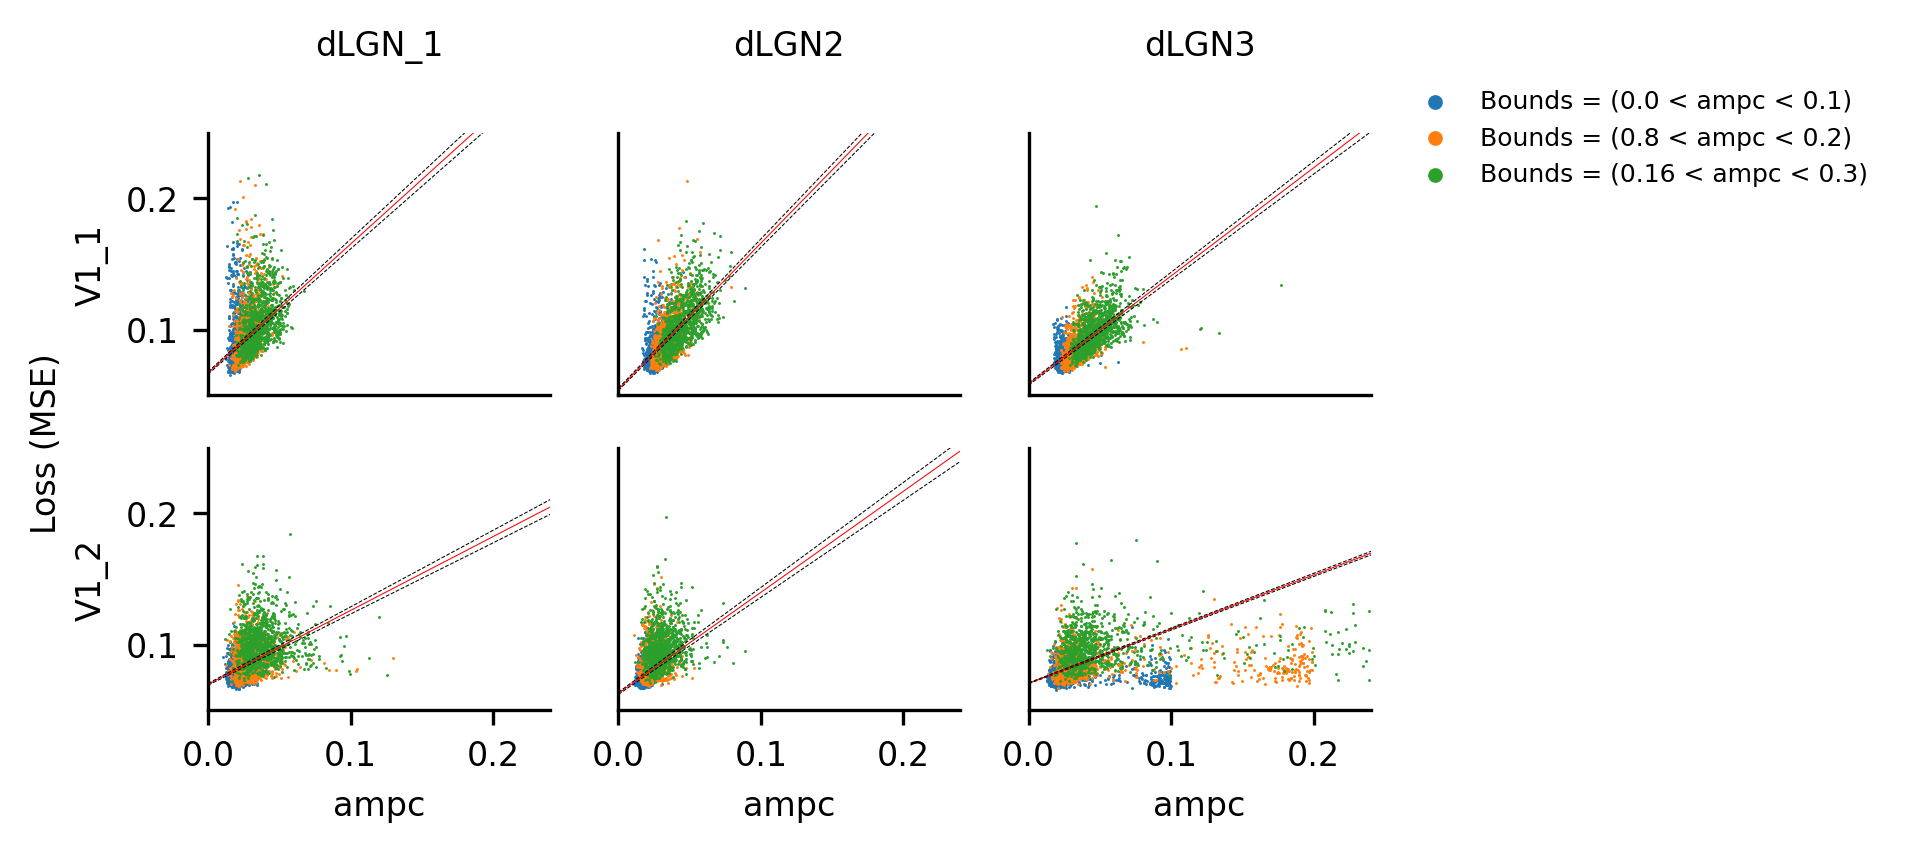

In [21]:
fig, ax = plt.subplots(2,3, figsize = (5,2.5))
ylabs = ['V1_1', 'V1_2']
titles = ['dLGN_1', 'dLGN2', 'dLGN3']
for row in range(2):
    ax[row, 0].set_ylabel(ylabs[row], fontsize = fontsize)
    for col in range(3):
        ax[0,col].set_title(titles[col], fontsize = fontsize, y = 1.2)
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, 0]
        if col>0:
            ax[row, col].set_yticks([])
        if row==0:
            ax[row, col].set_xticks([])
        else:
            ax[row, col].set_xlabel("ampc", fontsize = fontsize)
        ax[row, col].tick_params(labelsize = fontsize)
        ax[row, col].set_ylim(0.05,0.25)
        ax[row, col].set_xlim(0,0.24)
        x = np.linspace(0,0.3,100)
        y_lower, y, y_upper = draw_lm_line(row+1,col+1)
        ax[row,col].plot(x, y_lower, '--', linewidth = 0.25, color = 'black')
        ax[row,col].plot(x, y, linewidth = 0.25, color = 'red')
        ax[row,col].plot(x, y_upper, '--', linewidth = 0.25, color = 'black')
        for i in range(3):
            x = optimizations[row,col,i,0,:].flatten()
            y = optimizations[row,col,i,1,:].flatten()
            ax[row, col].scatter(x,y, s = 0.5, linewidth = 0, label = f"Bounds = {np.array(ylabels)[[0,2,4]][i].replace('V1_1 ','')}", rasterized=True)
ax[0,0].text(-0.125,-0.05, 'Loss (MSE)', fontsize = fontsize, rotation = 90)
ax[0,1].legend(
    fontsize = 6, 
    frameon = False, 
    markerscale = 5,
    bbox_to_anchor = (2.25,1.25)
)
fig.subplots_adjust(hspace=0.2)

# figname = 'ampc_perturbation_loss_scatterplots.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [22]:
optimizations.shape

(2, 3, 3, 2, 1000)

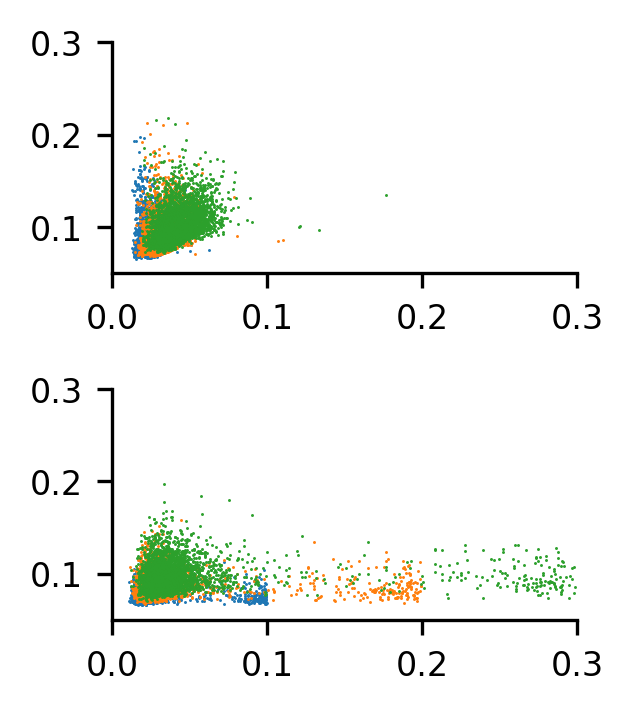

In [36]:
fig, ax = plt.subplots(2, figsize = (2,2.5))
ylabs = ['V1_1', 'V1_2']
titles = ['dLGN_1', 'dLGN2', 'dLGN3']
for row in range(2):
    ax[row].spines['top'].set_visible(False)
    ax[row].spines['right'].set_visible(False)
    ax[row].tick_params(labelsize = fontsize)
    ax[row].set_xlim(0,0.3)
    ax[row].set_ylim(0.05,0.3)

    for i in range(3):

        x = optimizations[row,:,i,0,:].flatten()
        y = optimizations[row,:,i,1,:].flatten()
        ax[row].scatter(
            x, y, s = 0.5, linewidth = 0, rasterized=True
        )

plt.subplots_adjust(hspace=0.5)

figname = 'ampc_perturbation_loss_scatterplots_v1_only.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

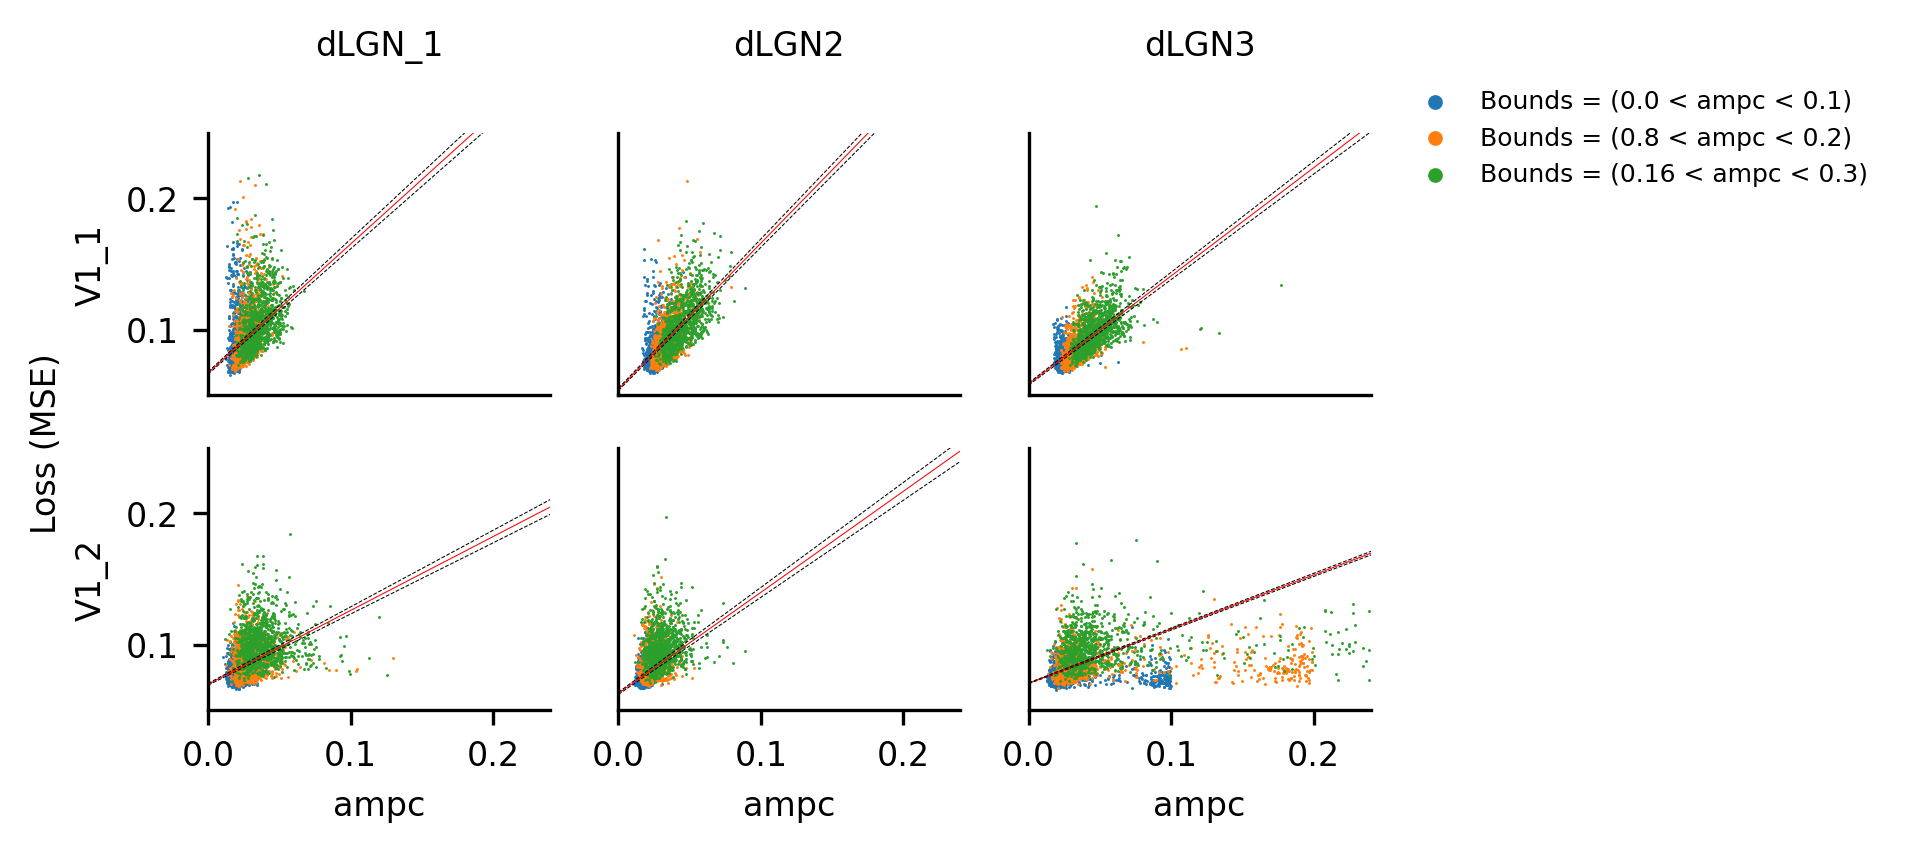

In [34]:
fig, ax = plt.subplots(2,3, figsize = (5,2.5))
ylabs = ['V1_1', 'V1_2']
titles = ['dLGN_1', 'dLGN2', 'dLGN3']
for row in range(2):
    ax[row, 0].set_ylabel(ylabs[row], fontsize = fontsize)
    for col in range(3):
        ax[0,col].set_title(titles[col], fontsize = fontsize, y = 1.2)
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, 0]
        if col>0:
            ax[row, col].set_yticks([])
        if row==0:
            ax[row, col].set_xticks([])
        else:
            ax[row, col].set_xlabel("ampc", fontsize = fontsize)
        ax[row, col].tick_params(labelsize = fontsize)
        ax[row, col].set_ylim(0.05,0.25)
        ax[row, col].set_xlim(0,0.24)
        x = np.linspace(0,0.3,100)
        y_lower, y, y_upper = draw_lm_line(row+1,col+1)
        ax[row,col].plot(x, y_lower, '--', linewidth = 0.25, color = 'black')
        ax[row,col].plot(x, y, linewidth = 0.25, color = 'red')
        ax[row,col].plot(x, y_upper, '--', linewidth = 0.25, color = 'black')
        for i in range(3):
            x = optimizations[row,col,i,0,:].flatten()
            y = optimizations[row,col,i,1,:].flatten()
            ax[row, col].scatter(x,y, s = 0.5, linewidth = 0, label = f"Bounds = {np.array(ylabels)[[0,2,4]][i].replace('V1_1 ','')}", rasterized=True)
ax[0,0].text(-0.125,-0.05, 'Loss (MSE)', fontsize = fontsize, rotation = 90)
ax[0,1].legend(
    fontsize = 6, 
    frameon = False, 
    markerscale = 5,
    bbox_to_anchor = (2.25,1.25)
)
fig.subplots_adjust(hspace=0.2)

# figname = 'ampc_perturbation_loss_scatterplots.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [24]:
def plot_global_coefs(row, ax):
    loc = row['Unnamed: 0']
    v1_unit = row.v1_unit
    upper_bound = row.upper_bound

    try:
        mean = row.emmean
    except:
        mean = row['ampc.trend']

    err = row.SE
    ax.errorbar(
        mean,
        loc,
        xerr = err,
        color = 'black',
        fmt='o',
        markersize = 2,
        elinewidth = 0.75,
        capsize = 2,
        capthick=0.5
    )

[Text(0, 1, 'V1_1 (0.0 < ampc < 0.1)'),
 Text(0, 2, 'V1_2 (0.0 < ampc < 0.1)'),
 Text(0, 3, 'V1_1 (0.8 < ampc < 0.2)'),
 Text(0, 4, 'V1_2 (0.8 < ampc < 0.2)'),
 Text(0, 5, 'V1_1 (0.16 < ampc < 0.3)'),
 Text(0, 6, 'V1_2 (0.16 < ampc < 0.3)')]

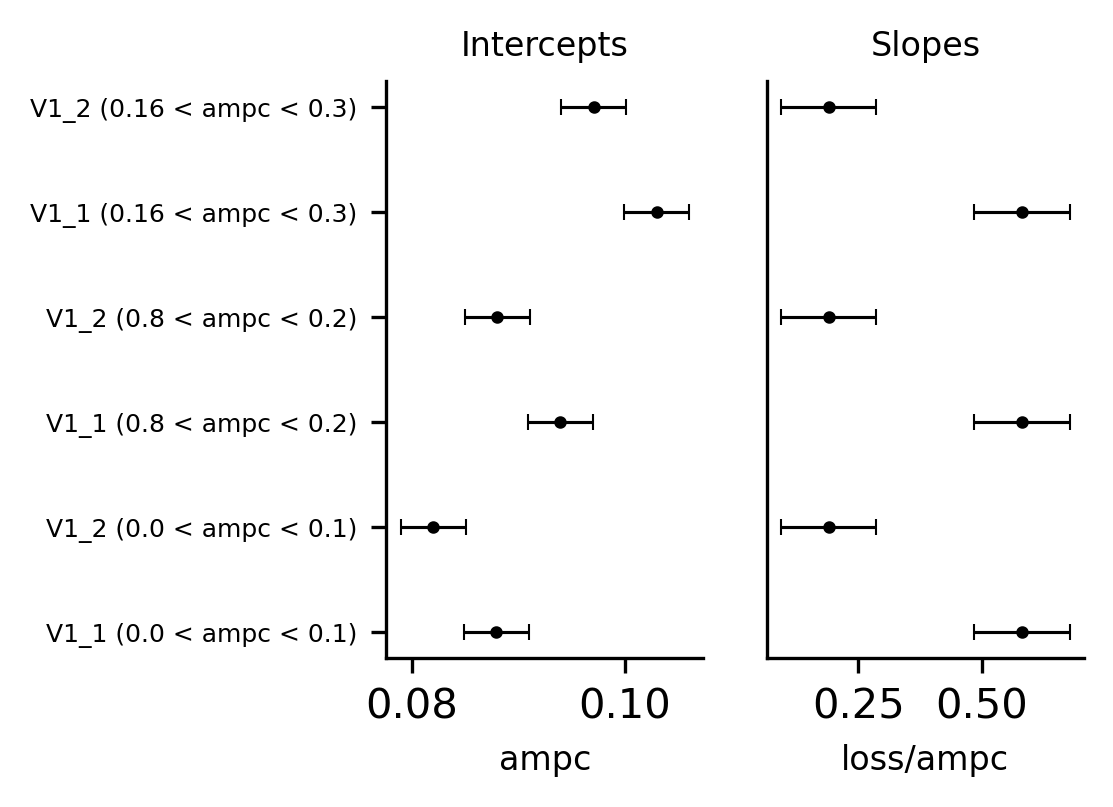

In [25]:
fig, ax = plt.subplots(1,2, figsize = (3,2.5))
titles = ['Intercepts', 'Slopes']
xlabels = ['ampc', 'loss/ampc']
for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_title(titles[i], fontsize = 8)
    ax[i].set_xlabel(xlabels[i], fontsize = 8)
gints.apply(plot_global_coefs, axis = 1, ax=ax[0])
gslopes.apply(plot_global_coefs, axis = 1, ax=ax[1])
ax[1].set_yticks([])
ax[0].set_yticks(np.arange(1,7))
ax[0].set_yticklabels(ylabels, fontsize = 6)

# figname = 'ampc_perturbation_lmer_coefs.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

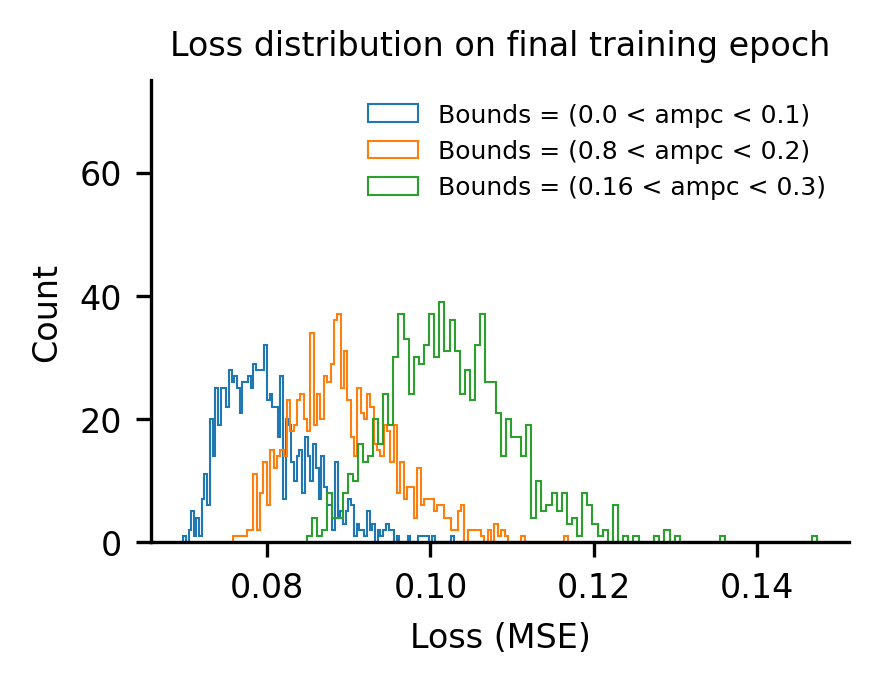

In [26]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_ylim(0,75)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
for i in range(3):
    y = optimizations[:,:,:,1,:].mean((0,1))[i]
    ax.hist(y, bins = 100, label = f"Bounds = {np.array(ylabels)[[0,2,4]][i].replace('V1_1 ','')}", histtype='step', linewidth = 0.5)

ax.legend(fontsize = 6, frameon = False)

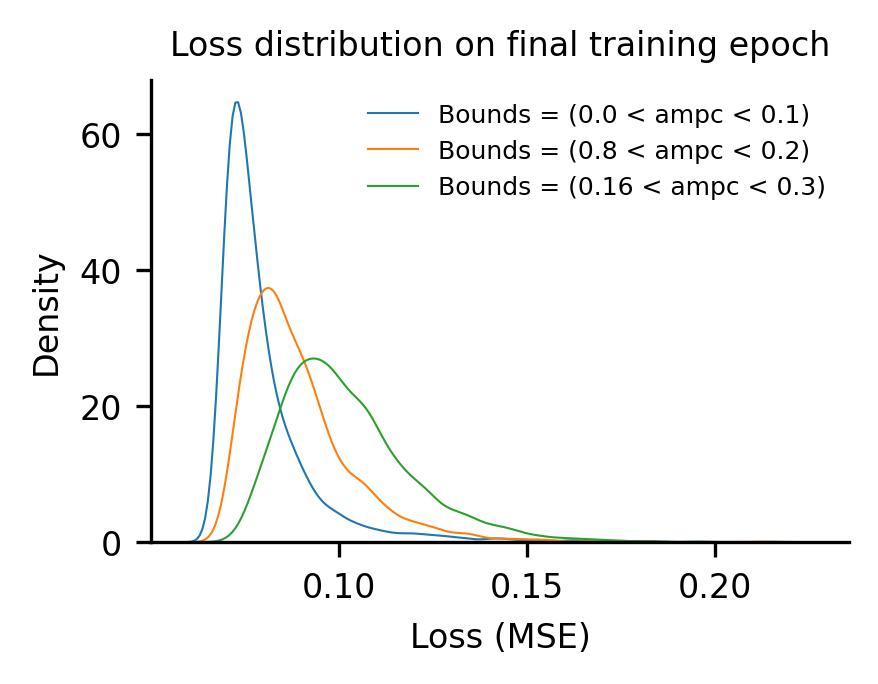

In [ ]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Density", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
#ax.set_ylim(0,8)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
for i in range(3):
    y = optimizations[:,:,i,1,:].flatten()
    sns.kdeplot(y, label = f"Bounds = {np.array(ylabels)[[0,2,4]][i].replace('V1_1 ','')}", linewidth = 0.5)

ax.legend(fontsize = 6, frameon = False)


# figname = 'ampc_perturbation_bound_condition_dists.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

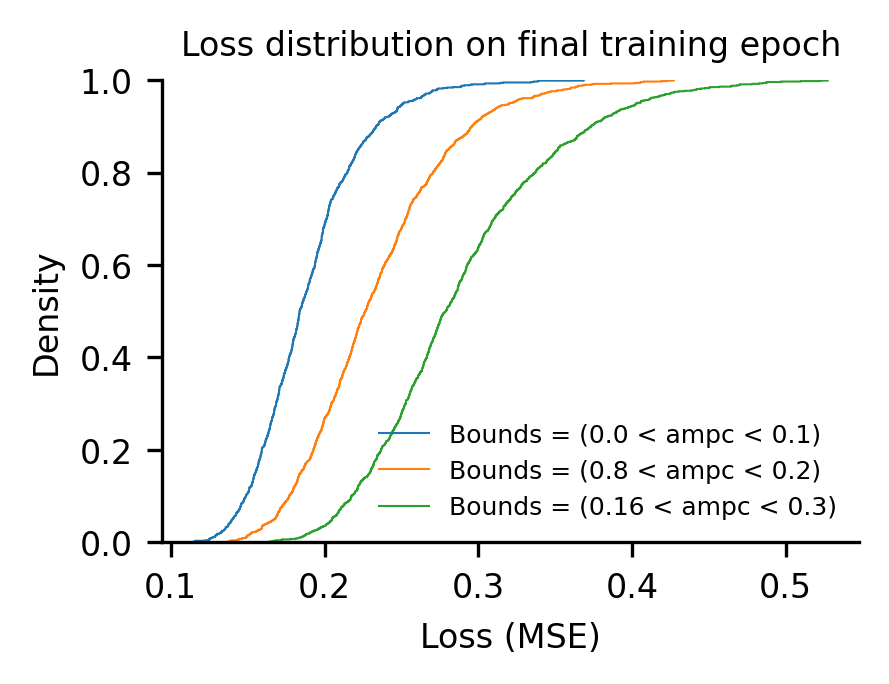

In [24]:
fig, ax = plt.subplots(figsize = (3,2))

ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Density", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
ax.set_ylim(0,1)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)
for i in range(3):
    y = optimizations[:,:,:,1,:].mean((0,1))[i]
    sns.ecdfplot(y, label = f"Bounds = {np.array(ylabels)[[0,2,4]][i].replace('V1_1 ','')}", linewidth = 0.5)

ax.legend(fontsize = 6, frameon = False)

In [25]:
for pair in list(combinations(np.arange(3), 2)):
    i, u = pair
    ref = optimizations[:,:,:,1,:].mean((0,1))[i]
    comp = optimizations[:,:,:,1,:].mean((0,1))[u]
    print(ttest_ind(ref, comp))

TtestResult(statistic=-23.49671891126805, pvalue=5.34595966730337e-108, df=1998.0)
TtestResult(statistic=-44.766681818014874, pvalue=1.0365499154868381e-303, df=1998.0)
TtestResult(statistic=-22.58021310536544, pvalue=9.694519674383315e-101, df=1998.0)
